In [1]:
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../logs', exist_ok=True)


class Tee:
    def __init__(self, *streams):
        self.streams = streams
        self.encoding = getattr(streams[0], 'encoding', 'utf-8')
    def write(self, data):
        for s in self.streams:
            s.write(data)
            s.flush()
    def flush(self):
        for s in self.streams:
            s.flush()


log_file = open('../logs/compare.txt', 'w')
sys.stdout = Tee(sys.__stdout__, log_file)
sys.stderr = Tee(sys.__stderr__, log_file)

In [2]:
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

result_files = [
    '../results/gru_tfidf_results.json',
    '../results/gru_skipgram_results.json',
    '../results/gru_cbow_results.json'
]

all_results = []
for f in result_files:
    with open(f) as fp:
        all_results.append(json.load(fp))

## comparison table 1: overall metrics

In [3]:
rows = []
for r in all_results:
    rows.append({
        'Model': r['model'],
        'Test Accuracy': round(r['test_accuracy'], 4),
        'Weighted F1': round(r['weighted_f1'], 4)
    })

overall_df = pd.DataFrame(rows)
print(overall_df.to_string(index=False))

## comparison table 2: per-class f1

In [4]:
rows = []
for r in all_results:
    row = {'Model': r['model']}
    for cls in CLASS_NAMES:
        row[cls] = round(r['per_class_f1'][cls], 4)
    rows.append(row)

perclass_df = pd.DataFrame(rows)
print(perclass_df.to_string(index=False))

## bar chart: accuracy and f1 comparison

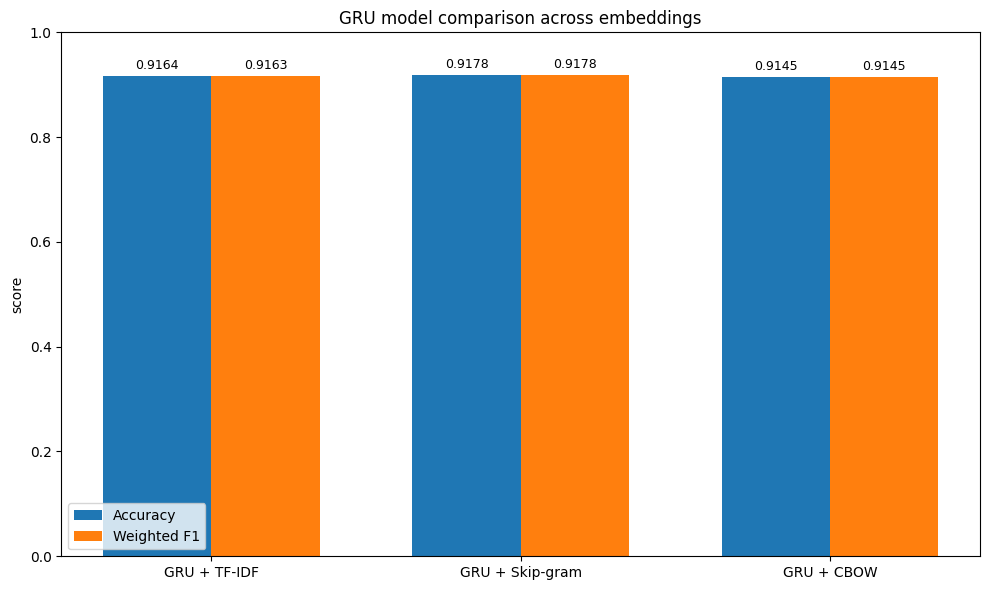

In [5]:
models = [r['model'] for r in all_results]
accuracies = [r['test_accuracy'] for r in all_results]
f1_scores = [r['weighted_f1'] for r in all_results]

x = range(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], accuracies, width, label='Accuracy')
bars2 = ax.bar([i + width/2 for i in x], f1_scores, width, label='Weighted F1')

ax.set_ylabel('score')
ax.set_title('GRU model comparison across embeddings')
ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/embedding_comparison.png', dpi=150)
plt.show()

## per-class f1 grouped bar chart

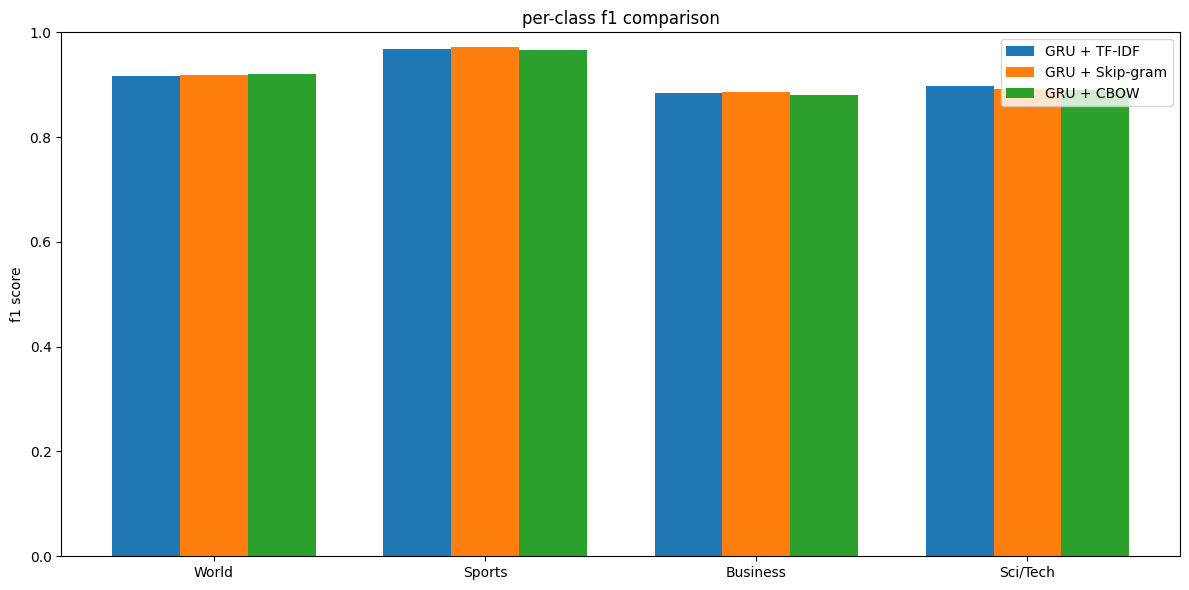

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(CLASS_NAMES))
n_models = len(all_results)
width = 0.25

for i, r in enumerate(all_results):
    values = [r['per_class_f1'][cls] for cls in CLASS_NAMES]
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar([j + offset for j in x], values, width, label=r['model'])

ax.set_ylabel('f1 score')
ax.set_title('per-class f1 comparison')
ax.set_xticks(list(x))
ax.set_xticklabels(CLASS_NAMES)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../results/perclass_f1_comparison.png', dpi=150)
plt.show()

## hyperparameter tuning comparison

In [7]:
for r in all_results:
    print(f"\n{r['model']}")
    print(f"best params: {r['best_params']}")
    tuning_df = pd.DataFrame(r['tuning_results'])
    print(tuning_df.to_string(index=False))

In [8]:
overall_df.to_csv('../results/overall_comparison.csv', index=False)
perclass_df.to_csv('../results/perclass_f1_comparison.csv', index=False)
print('comparison tables saved')